# Order Analysis

This notebook provides exploratory analysis of customer order data, including order patterns, distributions, and temporal trends.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
folder_path = '../../data/data1031'
file = 'order_result.csv'
file_path = os.path.join(folder_path, file)
columns = ["member_id", "dept_id", "create_hour", 
            "coffee_origin_money", "drink_not_coffee_origin_money", "food_origin_money",
            "coffee_commodity_num", "coffee_top_commodity_num",
            "not_coffee_commodity_num", "not_coffee_top_commodity_num",
            "food_commodity_num",
            "use_coupon_num",
            "coffee_discount", "disount_tag",
            "drink_not_coffee_discount"]
# only read the columns in the list
order_result = pd.read_csv(file_path, usecols=columns)
order_result['date'] = pd.to_datetime(order_result['create_hour'],
                                             format='%Y-%m-%d %H').dt.date
order_result['total_items'] = (order_result['coffee_commodity_num'] + 
                               order_result['not_coffee_commodity_num'])
order_result['total_top_items'] = (order_result['coffee_top_commodity_num'] + 
                                   order_result['not_coffee_top_commodity_num'])                                   
order_result['has_discount'] = (~order_result['coffee_discount'].isnull()) | (~order_result['drink_not_coffee_discount'].isnull())
order_result['drink_not_coffee_commodity_num'] = order_result['not_coffee_commodity_num'] - order_result['food_commodity_num']
# discard column 'create_hour'
order_result = order_result.drop(columns=['create_hour'])
order_result.head()

,member_id,coffee_commodity_num,coffee_top_commodity_num,not_coffee_commodity_num,not_coffee_top_commodity_num,food_commodity_num,use_coupon_num,coffee_origin_money,coffee_discount,drink_not_coffee_origin_money,drink_not_coffee_discount,food_origin_money,disount_tag,dept_id,date,total_items,total_top_items,has_discount,drink_not_coffee_commodity_num
0,1,2,0,0,0,0,1,61.0,0.5,0.0,NaN,0.0,0,238,2021-05-29,2,0,True,0
1,1,1,1,2,0,2,1,29.0,0.4,0.0,NaN,21.0,0,218,2021-06-29,3,1,True,0
2,1,0,0,3,0,2,1,0.0,NaN,35.0,0.5,21.0,0,218,2021-06-29,3,0,True,1
3,3,3,2,0,0,0,0,90.0,0.6,0.0,NaN,0.0,3,116,2021-06-08,3,2,True,0
4,3,1,1,0,0,0,0,32.0,0.6,0.0,NaN,0.0,3,98,2021-11-13,1,1,True,0


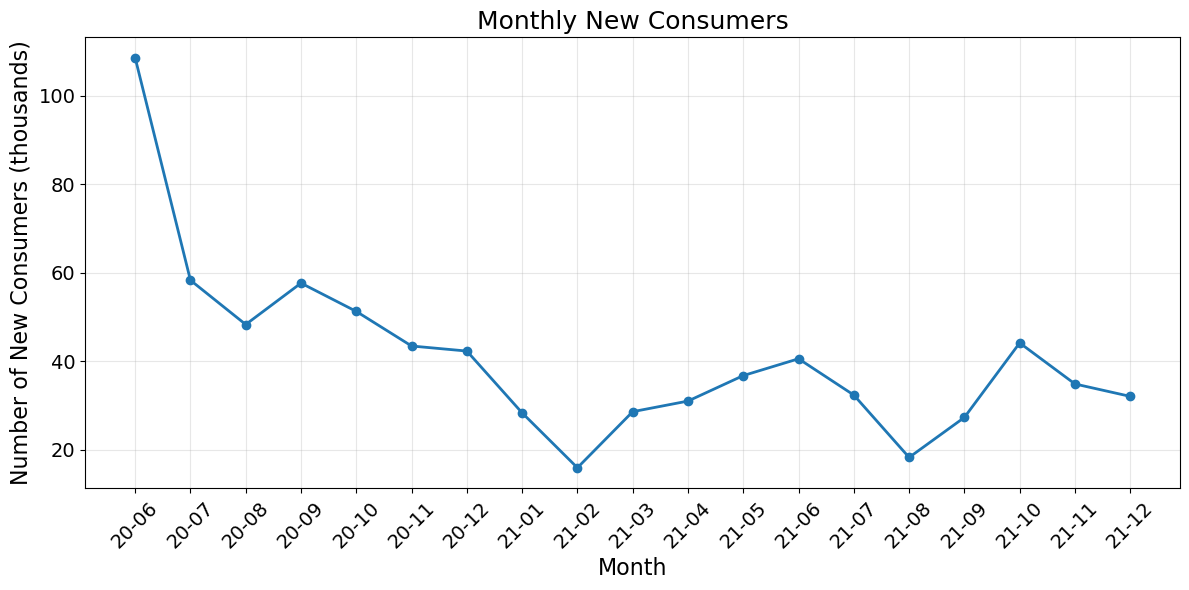

In [4]:
# Convert date column to datetime first
order_result['date'] = pd.to_datetime(order_result['date'])

# Find first purchase date for each member
first_purchases = order_result.groupby('member_id')['date'].min().reset_index()
first_purchases.columns = ['member_id', 'first_purchase_date']

# Extract month from first purchase date
first_purchases['month'] = pd.to_datetime(first_purchases['first_purchase_date']).dt.to_period('M')

# Count new consumers by month
monthly_new_consumers = first_purchases['month'].value_counts().sort_index()

# Convert period to string in format YY-MM
monthly_new_consumers.index = monthly_new_consumers.index.astype(str).str[2:]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_new_consumers.index, monthly_new_consumers.values/1000, marker='o', linewidth=2, markersize=6)
plt.title('Monthly New Consumers', fontsize=18)
plt.xlabel('Month', fontsize=16)
plt.ylabel('Number of New Consumers (thousands)', fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_new_consumers.pdf', dpi=300)
plt.show();

/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


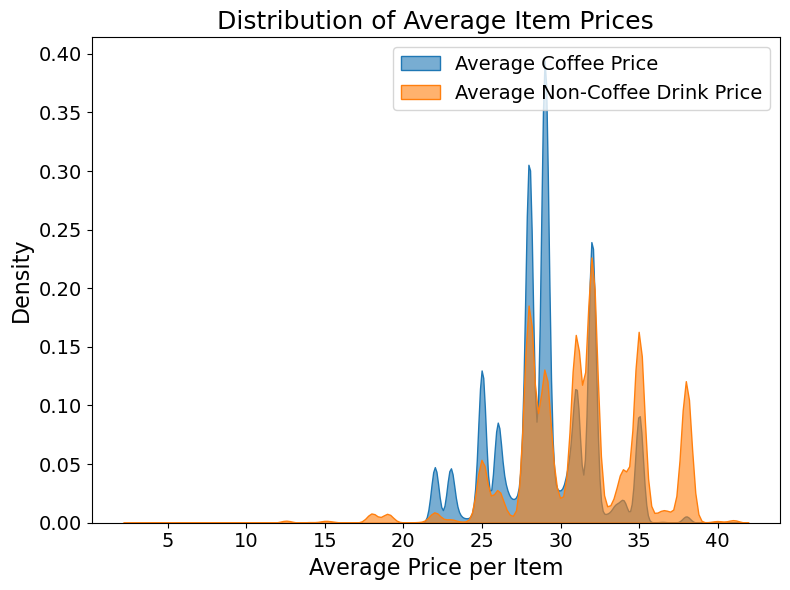

In [5]:
# Calculate average prices per item
order_result['avg_coffee_price'] = order_result['coffee_origin_money'] / order_result['coffee_commodity_num']
order_result['avg_drink_not_coffee_price'] = order_result['drink_not_coffee_origin_money'] / order_result['drink_not_coffee_commodity_num']

# Remove infinite values and NaN
filtered_data = order_result[
    (order_result['avg_coffee_price'].notna()) & 
    (order_result['avg_drink_not_coffee_price'].notna()) &
    (order_result['avg_coffee_price'] != float('inf')) &
    (order_result['avg_drink_not_coffee_price'] != 0)
]

plt.figure(figsize=(8, 6))

sns.kdeplot(data=filtered_data, x='avg_coffee_price', label='Average Coffee Price', color='#1f77b4', fill=True, alpha=0.6)
sns.kdeplot(data=filtered_data, x='avg_drink_not_coffee_price', label='Average Non-Coffee Drink Price', color='#ff7f0e', fill=True, alpha=0.6)

plt.title('Distribution of Average Item Prices', fontsize=18)
plt.xlabel('Average Price per Item', fontsize=16)
plt.ylabel('Density', fontsize=16)
plt.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig('average_item_prices.pdf', dpi=300)
plt.show();

In [6]:
# Summarize number of orders on each day per dept_id
daily_orders_by_dept = order_result.groupby(['date', 'dept_id']).size().reset_index(name='num_orders')

# Display summary statistics
print("Summary: Number of orders per day by dept_id")
print("=" * 50)
print(f"Total number of date-dept combinations: {len(daily_orders_by_dept)}")
print(f"\nNumber of unique dates: {daily_orders_by_dept['date'].nunique()}")
print(f"Number of unique dept_ids: {daily_orders_by_dept['dept_id'].nunique()}")
print(f"\nSummary statistics of orders per day per dept:")
print(daily_orders_by_dept['num_orders'].describe())

# Show sample data (first 20 rows)
print("\n" + "=" * 50)
print("Sample data (first 20 rows):")
print(daily_orders_by_dept.head(20))

# Pivot table for easier visualization (optional)
pivot_table = daily_orders_by_dept.pivot_table(
    index='date', 
    columns='dept_id', 
    values='num_orders', 
    fill_value=0
)
print("\n" + "=" * 50)
print("Pivot table sample (first 10 dates, all dept_ids):")
print(pivot_table.head(10))


Summary: Number of orders per day by dept_id
Total number of date-dept combinations: 102969

Number of unique dates: 579
Number of unique dept_ids: 260

Summary statistics of orders per day per dept:
count    102969.000000
mean         71.016500
std          41.627151
min           1.000000
25%          42.000000
50%          64.000000
75%          91.000000
max         560.000000
Name: num_orders, dtype: float64

Sample data (first 20 rows):
         date  dept_id  num_orders
0  2020-06-01        1          68
1  2020-06-01       16          35
2  2020-06-01       17          40
3  2020-06-01       18          48
4  2020-06-01       19          71
5  2020-06-01       20          26
6  2020-06-01       21          66
7  2020-06-01       22          59
8  2020-06-01       23          67
9  2020-06-01       24          71
10 2020-06-01       25          40
11 2020-06-01       26          73
12 2020-06-01       27          49
13 2020-06-01       28          51
14 2020-06-01       29      

Summary statistics of orders per member:
count    779757.000000
mean          9.378358
std          20.190385
min           1.000000
25%           1.000000
50%           3.000000
75%           9.000000
max        3118.000000
Name: total_orders, dtype: float64

Total number of unique members: 779757


/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


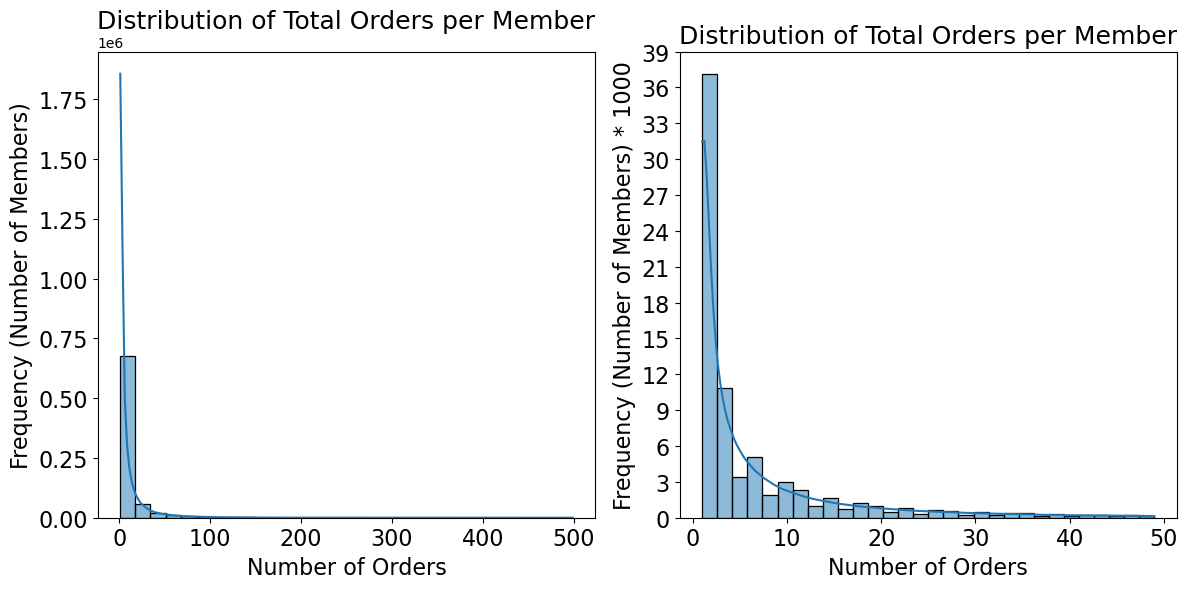

In [7]:
# Calculate total orders per member
orders_per_member = order_result['member_id'].value_counts().reset_index()
orders_per_member.columns = ['member_id', 'total_orders']

print("Summary statistics of orders per member:")
print(orders_per_member['total_orders'].describe())
print(f"\nTotal number of unique members: {len(orders_per_member)}")

filtered_orders_per_member500 = orders_per_member[orders_per_member['total_orders'] < 500]
filtered_orders_per_member50 = orders_per_member[orders_per_member['total_orders'] < 50]

# Create the frequency plot
plt.figure(figsize=(12, 6))
# Plot 1: Distribution of total orders per member
plt.subplot(1, 2, 1)
sns.histplot(data=filtered_orders_per_member500, x='total_orders', bins=30, kde=True)
plt.title('Distribution of Total Orders per Member', fontsize=18)
plt.xlabel('Number of Orders', fontsize=16)
plt.ylabel('Frequency (Number of Members)', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# Plot 2: Box plot to show the spread
plt.subplot(1, 2, 2)
sns.histplot(data=filtered_orders_per_member50, x='total_orders', bins=30, kde=True)
plt.title('Distribution of Total Orders per Member', fontsize=18)
plt.xlabel('Number of Orders', fontsize=16)
plt.ylabel('Frequency (Number of Members) * 1000', fontsize=16)
plt.xticks(fontsize=16)
# make y ticks as xxx*1000
ax = plt.gca()
max_y = ax.get_ylim()[1]
y_ticks = [i * 1000 for i in range(0, int(max_y // 1000) + 2, 30)]
plt.yticks(y_ticks, [str(int(i/10000)) for i in y_ticks], fontsize=16)
plt.tight_layout()
plt.savefig('order_distribution_by_member.pdf', dpi=300)
plt.show();

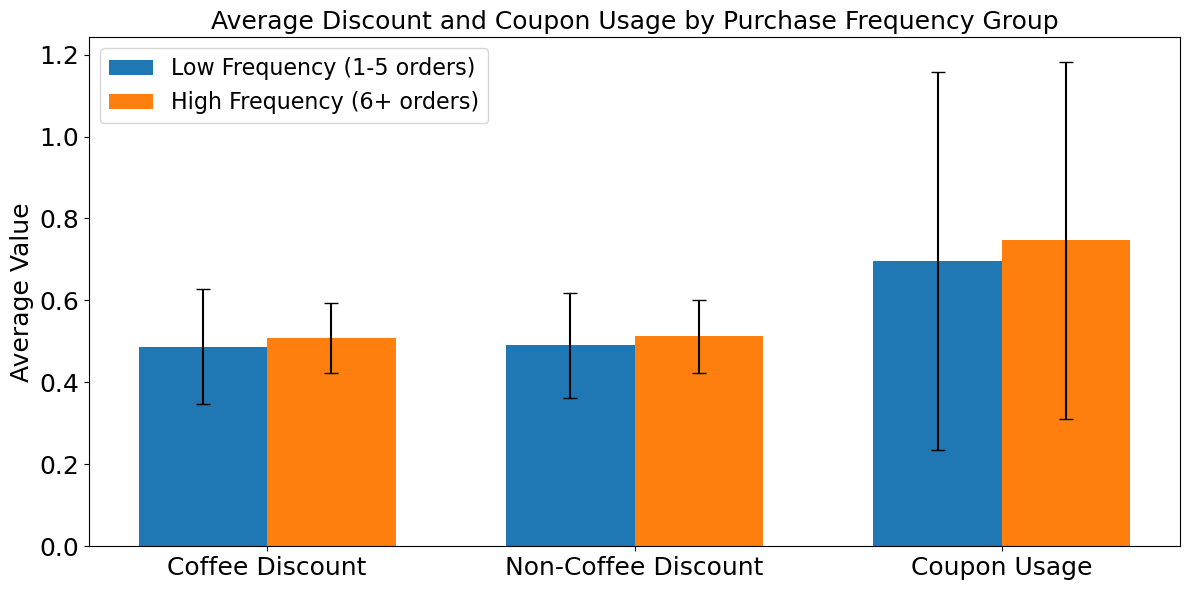

In [8]:
# Create groups based on purchase frequency
order_result['purchase_group'] = order_result['member_id'].map(
    orders_per_member.set_index('member_id')['total_orders']
).apply(lambda x: 'Low Frequency (1-5 orders)' if x <= 5 else 'High Frequency (6+ orders)')

# Calculate average metrics by group
group_stats = order_result.groupby('purchase_group').agg({
    'coffee_discount': ['mean', 'std'],
    'drink_not_coffee_discount': ['mean', 'std'],
    'use_coupon_num': ['mean', 'std']
}).round(3)
# Flatten column names
group_stats.columns = ['_'.join(col).strip() for col in group_stats.columns.values]
group_stats = group_stats.reset_index()

# Plot
metrics = ['coffee_discount', 'drink_not_coffee_discount', 'use_coupon_num']
x_pos = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(12, 6))

for i, group in enumerate(['Low Frequency (1-5 orders)', 'High Frequency (6+ orders)']):
    group_data = group_stats[group_stats['purchase_group'] == group]
    means = [group_data[f'{metric}_mean'].values[0] for metric in metrics]
    stds = [group_data[f'{metric}_std'].values[0] for metric in metrics]
    
    plt.bar(x_pos + i*width, means, width, label=group, yerr=stds, capsize=5)

plt.title('Average Discount and Coupon Usage by Purchase Frequency Group', fontsize=18)
# no x label
plt.xlabel('', fontsize=18)
plt.ylabel('Average Value', fontsize=18)
plt.xticks(x_pos + width/2, ['Coffee Discount', 'Non-Coffee Discount', 'Coupon Usage'],fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig('discount_and_coupon_by_purchase_frequency.pdf', dpi=300)
plt.show();

In [9]:
# Extract members with 5-50 orders
members_5_to_50 = orders_per_member[
    (orders_per_member['total_orders'] >= 5) & 
    (orders_per_member['total_orders'] <= 50)
]

print(f"Number of members with 5-50 orders: {len(members_5_to_50)}")
print(f"Percentage of total members: {len(members_5_to_50)/len(orders_per_member)*100:.2f}%")

# Filter the original data for these members
filtered_data = order_result[order_result['member_id'].isin(members_5_to_50['member_id'])]


Number of members with 5-50 orders: 273473
Percentage of total members: 35.07%


/tmp/ipykernel_3385496/1822918137.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['month'] = pd.to_datetime(filtered_data['date']).dt.to_period('M')


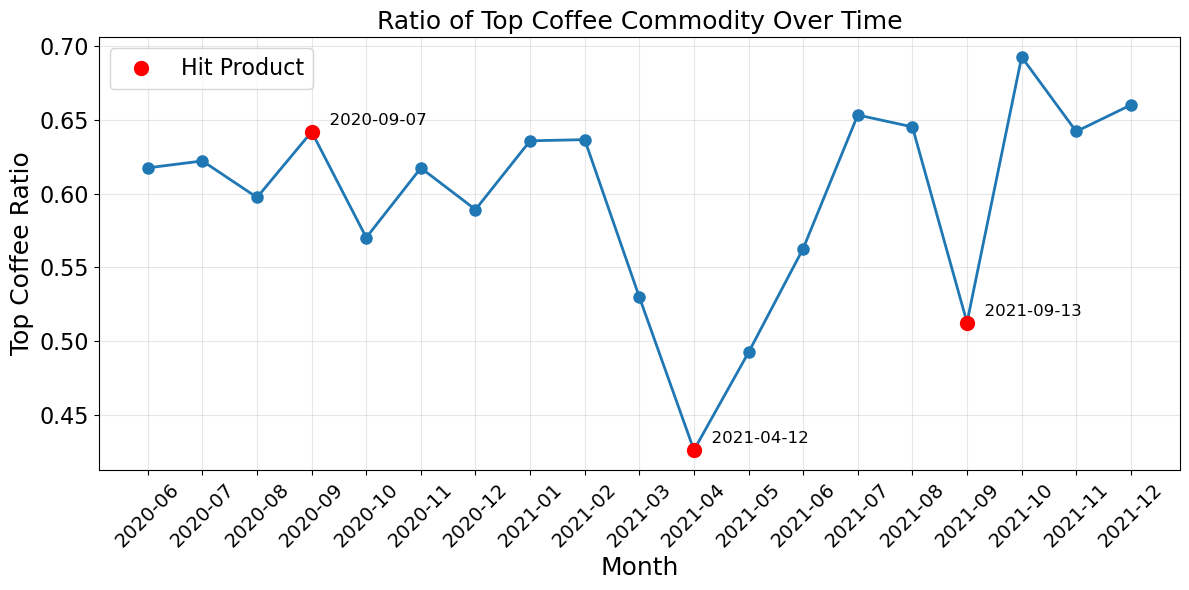

In [10]:
# Extract month from create_hour
filtered_data['month'] = pd.to_datetime(filtered_data['date']).dt.to_period('M')

# Calculate ratio of top coffee commodity by month
monthly_ratio = filtered_data.groupby('month').apply(
    lambda x: x['coffee_top_commodity_num'].sum() / x['coffee_commodity_num'].sum() 
    if x['coffee_commodity_num'].sum() > 0 else 0
).reset_index()
monthly_ratio.columns = ['month', 'top_coffee_ratio']

# Convert period to string for plotting
monthly_ratio['month_str'] = monthly_ratio['month'].astype(str)

# Mark specific dates
mark_dates = ['2020-09-07', '2021-04-12', '2021-09-13']
mark_months = [pd.to_datetime(date).strftime('%Y-%m') for date in mark_dates]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_ratio['month_str'], monthly_ratio['top_coffee_ratio'], marker='o', linewidth=2, markersize=8)

# Mark specific months with exact dates
for i, month in enumerate(mark_months):
    if month in monthly_ratio['month_str'].values:
        idx = monthly_ratio[monthly_ratio['month_str'] == month].index[0]
        plt.annotate(f'  {mark_dates[i]}', 
                    (monthly_ratio['month_str'].iloc[idx], monthly_ratio['top_coffee_ratio'].iloc[idx]),
                    textcoords="offset points", xytext=(5,5), ha='left', fontsize=12,
                    arrowprops=dict(arrowstyle='wedge', color='red'))
        plt.plot(monthly_ratio['month_str'].iloc[idx], monthly_ratio['top_coffee_ratio'].iloc[idx], 
                'ro', markersize=10, label='Hit Product' if i == 0 else "")

plt.title('Ratio of Top Coffee Commodity Over Time', fontsize=18)
plt.xlabel('Month', fontsize=18)
plt.ylabel('Top Coffee Ratio', fontsize=18)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig('top_coffee_ratio_over_time.pdf', dpi=300)
plt.show();

Percentage of coffee orders with #coupon > 1: 0.06%
Percentage of coffee orders with discount > 1: 0.01%


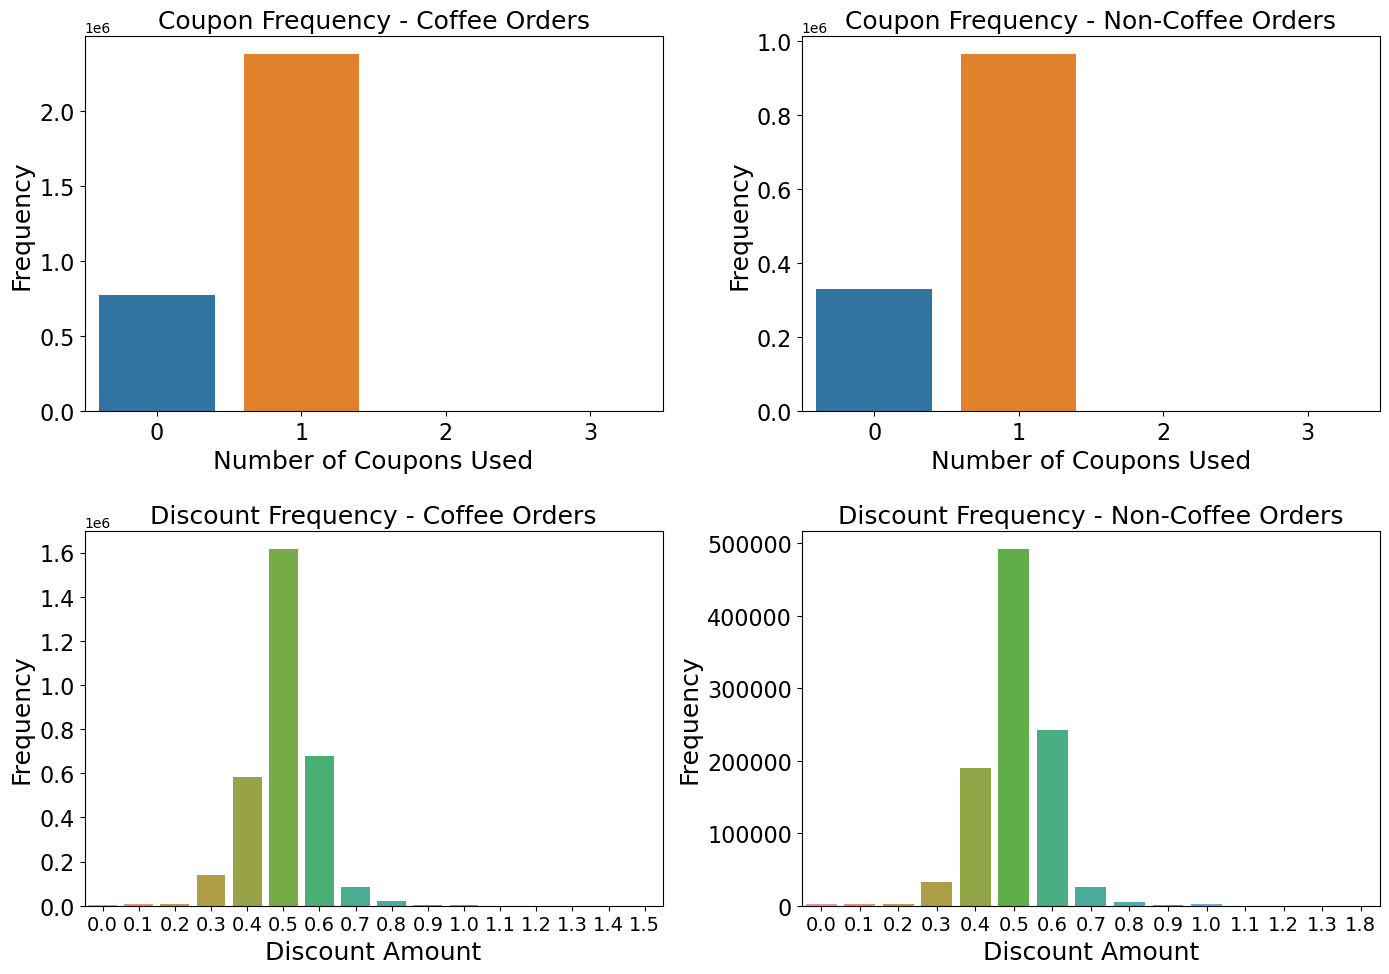

In [11]:
# Calculate coupon usage frequency for coffee and non-coffee orders
coffee_orders = filtered_data[filtered_data['coffee_commodity_num'] > 0]
non_coffee_orders = filtered_data[filtered_data['not_coffee_commodity_num'] > 0]

coffee_coupon_freq = coffee_orders['use_coupon_num'].value_counts().sort_index()
non_coffee_coupon_freq = non_coffee_orders['use_coupon_num'].value_counts().sort_index()

# Calculate discount frequency for coffee and non-coffee orders
coffee_discount_freq = coffee_orders['coffee_discount'].value_counts().sort_index()
non_coffee_discount_freq = non_coffee_orders['drink_not_coffee_discount'].value_counts().sort_index()

# Plot 2x2 figure
plt.figure(figsize=(14, 10))

# Coupon Frequency - Coffee
plt.subplot(2, 2, 1)
sns.barplot(x=coffee_coupon_freq.index, y=coffee_coupon_freq.values)
plt.title('Coupon Frequency - Coffee Orders', fontsize=18)
plt.xlabel('Number of Coupons Used', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Coupon Frequency - Non-Coffee
plt.subplot(2, 2, 2)
sns.barplot(x=non_coffee_coupon_freq.index, y=non_coffee_coupon_freq.values)
plt.title('Coupon Frequency - Non-Coffee Orders', fontsize=18)
plt.xlabel('Number of Coupons Used', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Discount Frequency - Coffee
plt.subplot(2, 2, 3)
sns.barplot(x=coffee_discount_freq.index, y=coffee_discount_freq.values)
plt.title('Discount Frequency - Coffee Orders', fontsize=18)
plt.xlabel('Discount Amount', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=16)

# Discount Frequency - Non-Coffee
plt.subplot(2, 2, 4)
sns.barplot(x=non_coffee_discount_freq.index, y=non_coffee_discount_freq.values)
plt.title('Discount Frequency - Non-Coffee Orders', fontsize=18)
plt.xlabel('Discount Amount', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=16)

plt.tight_layout()

# Calculate percentage of coupon used larger than 1
coffee_coupon_above_1 = (coffee_orders['use_coupon_num'] > 1).sum() / len(coffee_orders) * 100
print(f"Percentage of coffee orders with #coupon > 1: {coffee_coupon_above_1:.2f}%")

# Calculate percentage of discounts larger than 1
coffee_discount_above_1 = (coffee_orders['coffee_discount'] > 1).sum() / len(coffee_orders) * 100
print(f"Percentage of coffee orders with discount > 1: {coffee_discount_above_1:.2f}%")

plt.savefig('coupon_and_discount_frequency.pdf', dpi=300)
plt.show();

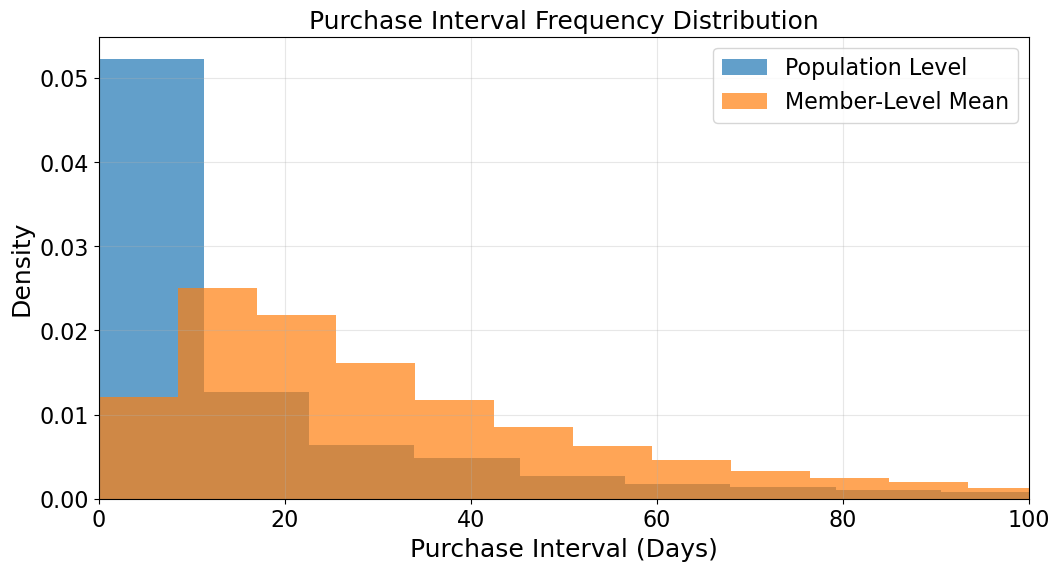

In [12]:
filtered_data_interval = filtered_data.sort_values(['member_id', 'date'])
filtered_data_interval['date'] = pd.to_datetime(filtered_data_interval['date'])
# Calculate shopping intervals
filtered_data_interval['prev_datetime'] = filtered_data_interval.groupby('member_id')['date'].shift(1)
filtered_data_interval['shopping_interval'] = (filtered_data_interval['date'] - filtered_data_interval['prev_datetime']).dt.days

# Remove first order for each member (no previous order)
intervals = filtered_data_interval['shopping_interval'].dropna()

# Calculate member-level mean intervals
member_mean_intervals = filtered_data_interval.groupby('member_id')['shopping_interval'].mean().dropna()

# Plot
plt.figure(figsize=(12, 6))

# Population level frequency
plt.hist(intervals, bins=50, alpha=0.7, label='Population Level', density=True)

# Member-level mean frequency
plt.hist(member_mean_intervals, bins=50, alpha=0.7, label='Member-Level Mean', density=True)

plt.title('Purchase Interval Frequency Distribution', fontsize=18)
plt.xlabel('Purchase Interval (Days)', fontsize=18)
plt.ylabel('Density', fontsize=18)
# x scale 0-100
plt.xlim(0, 100)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, alpha=0.3)

plt.savefig('purchase_interval_frequency.pdf', dpi=300)
plt.show();
#This shows that members keep buying in a period, but stop for a while.  

/tmp/ipykernel_3385496/1628022646.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['date'] = pd.to_datetime(filtered_data['date'])


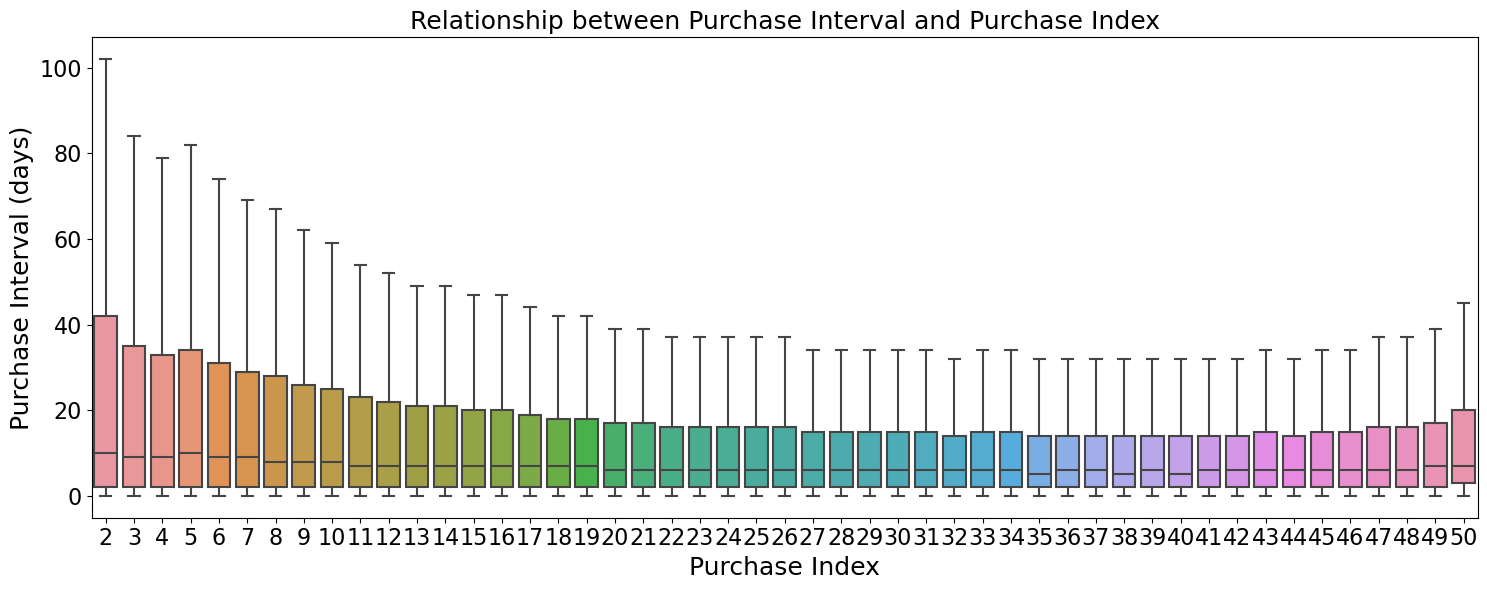

In [13]:
# Optimized version using vectorized operations
def get_purchase_intervals_fast(order_df, max_index=50):
    # Sort once and group
    sorted_df = order_df.sort_values(['member_id', 'date'])
    
    # Calculate intervals using vectorized operations
    sorted_df['interval_days'] = sorted_df.groupby('member_id')['date'].diff().dt.days
    
    # Remove first purchase (no interval) and filter by max_index
    intervals_df = sorted_df[sorted_df['interval_days'].notna()].copy()
    
    # Calculate purchase index using cumcount
    intervals_df['purchase_index'] = intervals_df.groupby('member_id').cumcount() + 2
    
    # Filter by max_index and return only needed columns
    result = intervals_df[intervals_df['purchase_index'] <= max_index][['purchase_index', 'interval_days']]
    
    return result

filtered_data['date'] = pd.to_datetime(filtered_data['date'])
purchase_interval_df = get_purchase_intervals_fast(filtered_data, 50)

# Boxplot: Purchase interval vs purchase index
plt.figure(figsize=(15, 6))
sns.boxplot(data=purchase_interval_df, x='purchase_index', y='interval_days', showfliers=False)
plt.xlabel('Purchase Index', fontsize=18)
plt.ylabel('Purchase Interval (days)', fontsize=18)
plt.title('Relationship between Purchase Interval and Purchase Index', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()

plt.savefig('purchase_interval_vs_purchase_index.pdf', dpi=300)
plt.show();

number of orders for discount 0.3 287392
number of orders for discount 0.4 1169708
count    771810.000000
mean         58.885113
std          80.799932
min           1.000000
25%           7.000000
50%          27.000000
75%          75.000000
max         575.000000
Name: interval, dtype: float64
number of orders for discount 0.5 3833305
number of orders for discount 0.6 1647869
number of orders for discount 0.7 177885
number of orders for discount 0.8 50492


/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/litao/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert in

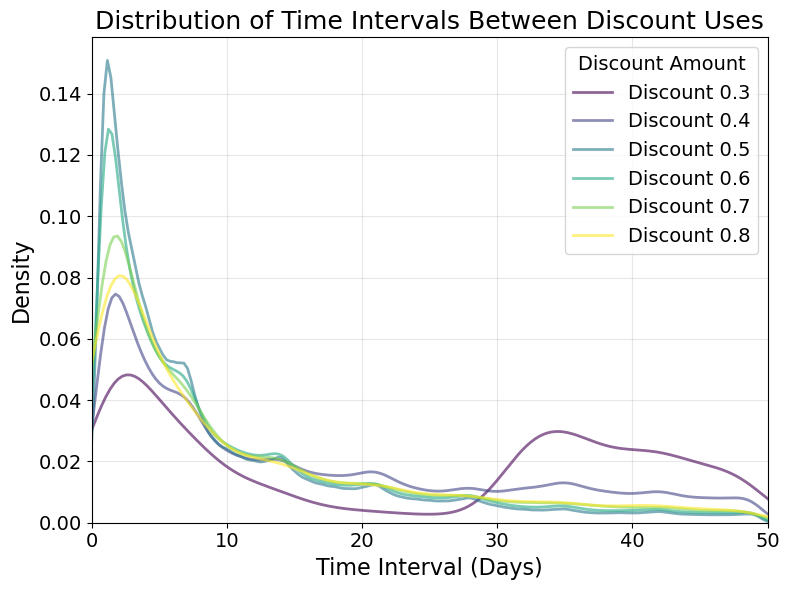

In [37]:
# Consider both coffee and non-coffee orders
# For each discount amount (0.3, 0.4, 0.5, 0.6, 0.7, 0.8), compute time intervals between uses at individual level

# Combine coffee and non-coffee discounts into a single discount column
# For each order, take the discount value (either coffee or non-coffee)
order_result['combined_discount'] = np.where(
    order_result['coffee_discount'].notna(),
    order_result['coffee_discount'],
    order_result['drink_not_coffee_discount']
)
# Filter orders that have discounts in the specified amounts
discount_amounts = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
order_result['date'] = pd.to_datetime(order_result['date'])

# Vectorized approach to calculate intervals
all_intervals = {}

for discount_amt in discount_amounts:
    # Filter for current discount amount
    current_discount_orders = order_result[order_result['combined_discount'] == discount_amt]
    print('number of orders for discount', discount_amt, len(current_discount_orders))
    # Calculate intervals using groupby and diff
    current_discount_orders = current_discount_orders.copy()
    current_discount_orders['interval'] = current_discount_orders.groupby('member_id')['date'].diff().dt.days
    
    # Extract valid intervals (not NaN and positive)
    intervals = current_discount_orders['interval'].dropna()
    intervals = intervals[intervals > 0]
    if discount_amt == 0.4:
        print(intervals.describe())
    all_intervals[discount_amt] = intervals.tolist()

# Plot distributions in the same plot
plt.figure(figsize=(8, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(discount_amounts)))

for i, discount_amt in enumerate(discount_amounts):
    intervals = np.array(all_intervals[discount_amt])
    if len(intervals) > 0:
        intervals = intervals[intervals < 50]
        sns.kdeplot(x=intervals, alpha=0.6, label=f'Discount {discount_amt}', 
                color=colors[i], linewidth=2, fill=False)

plt.title('Distribution of Time Intervals Between Discount Uses', fontsize=18)
plt.xlabel('Time Interval (Days)', fontsize=16)
plt.ylabel('Density', fontsize=16)
plt.legend(fontsize=14, title='Discount Amount', title_fontsize=14)
plt.xlim(0, 50)  # Limit x-axis to focus on most common intervals
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('discount_interval_distribution.pdf', dpi=300)
plt.show();
